# Preprossesing BTS On Time Performance Data 2019-2026.

# 1-  COUNT HOW MUCH NULL VALUES IN EACH COLUMN of all files

In [1]:
import pandas as pd
import os

# Base directory where all your yearly CSVs are located
base_dir = '/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv'

# Define the range of years you want to check
years = range(2019, 2027)  # This generates integers from 2019 to 2025

print("--- Processing Null Values Across Years (2019-2026) ---")

for year in years:
    # Dynamically build the file path for each year
    file_path = os.path.join(base_dir, f'bts_ontime_{year}.csv')
    
    if os.path.exists(file_path):
        print(f"\nProcessing Year: {year}...")
        
        # Memory-saving tip: use usecols if you only want specific columns,
        # but since we want all nulls, low_memory=False is good.
        df = pd.read_csv(file_path, low_memory=False)
        print(f"  -> Successfully loaded {len(df):,} rows.")
        
        # Calculate null counts
        null_counts = df.isnull().sum()
        columns_with_nulls = null_counts[null_counts > 0]
        
        if not columns_with_nulls.empty:
            print(f"  -> Columns with Null Values in {year}:")
            # Loop to print beautifully formatted results
            for col, count in columns_with_nulls.items():
                percentage = (count / len(df)) * 100
                print(f"     - {col}: {count:,} nulls ({percentage:.2f}%)")
        else:
            print(f"  -> Awesome! No null values found in {year}.")
            
        # Crucial: Delete the dataframe from memory before the next loop iteration
        del df
        
    else:
        print(f"\n[Warning] File not found for year {year}: {file_path}")

--- Processing Null Values Across Years (2019-2026) ---

Processing Year: 2019...
  -> Successfully loaded 7,422,037 rows.
  -> Columns with Null Values in 2019:
     - Tail_Number: 17,837 nulls (0.24%)
     - DepTime: 130,086 nulls (1.75%)
     - DepDelay: 130,110 nulls (1.75%)
     - DepDelayMinutes: 130,110 nulls (1.75%)
     - ArrTime: 137,646 nulls (1.85%)
     - ArrDelay: 153,805 nulls (2.07%)
     - ArrDelayMinutes: 153,805 nulls (2.07%)
     - CancellationCode: 7,287,112 nulls (98.18%)
     - CRSElapsedTime: 135 nulls (0.00%)
     - ActualElapsedTime: 153,805 nulls (2.07%)
     - AirTime: 153,805 nulls (2.07%)
     - CarrierDelay: 6,032,784 nulls (81.28%)
     - WeatherDelay: 6,032,784 nulls (81.28%)
     - NASDelay: 6,032,784 nulls (81.28%)
     - SecurityDelay: 6,032,784 nulls (81.28%)
     - LateAircraftDelay: 6,032,784 nulls (81.28%)

Processing Year: 2020...
  -> Successfully loaded 4,688,354 rows.
  -> Columns with Null Values in 2020:
     - Tail_Number: 153,948 nulls (3

# 2- DELETE THE WHOLE ROW IF THE TAIL NUMBER DOESN'T EXIST.

In [2]:
# Source directory (Read-only input)
base_dir = '/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv'

# Output directory (Writable workspace)
output_dir = '/kaggle/working/clean_dataset'
os.makedirs(output_dir, exist_ok=True)

print("--- Step 2: Dropping Rows Missing Tail Numbers ---")

# Automatically find all bts_ontime files in the directory
files = sorted([f for f in os.listdir(base_dir) if f.startswith('bts_ontime_') and f.endswith('.csv')])

for file_name in files:
    file_path = os.path.join(base_dir, file_name)
    print(f"\nProcessing File: {file_name}...")
    
    # Load the data
    df = pd.read_csv(file_path, low_memory=False)
    initial_rows = len(df)
    
    # Drop rows where Tail_Number is null
    df = df.dropna(subset=['Tail_Number'])
    final_rows = len(df)
    dropped_rows = initial_rows - final_rows
    
    print(f"  -> Original rows: {initial_rows:,}")
    print(f"  -> Dropped {dropped_rows:,} rows missing a Tail Number.")
    print(f"  -> Remaining rows: {final_rows:,}")
    
    # Save the cleaned file to the writable output directory
    output_file_path = os.path.join(output_dir, file_name.replace('.csv', '_clean.csv'))
    df.to_csv(output_file_path, index=False)
    print(f"  -> Saved clean file to: {output_file_path}")
    
    # Explicitly free up memory
    del df

print("\n--- Preprocessing Step 2 Complete! ---")

--- Step 2: Dropping Rows Missing Tail Numbers ---

Processing File: bts_ontime_2019.csv...
  -> Original rows: 7,422,037
  -> Dropped 17,837 rows missing a Tail Number.
  -> Remaining rows: 7,404,200
  -> Saved clean file to: /kaggle/working/clean_dataset/bts_ontime_2019_clean.csv

Processing File: bts_ontime_2020.csv...
  -> Original rows: 4,688,354
  -> Dropped 153,948 rows missing a Tail Number.
  -> Remaining rows: 4,534,406
  -> Saved clean file to: /kaggle/working/clean_dataset/bts_ontime_2020_clean.csv

Processing File: bts_ontime_2021.csv...
  -> Original rows: 5,995,397
  -> Dropped 16,394 rows missing a Tail Number.
  -> Remaining rows: 5,979,003
  -> Saved clean file to: /kaggle/working/clean_dataset/bts_ontime_2021_clean.csv

Processing File: bts_ontime_2022.csv...
  -> Original rows: 6,729,125
  -> Dropped 34,560 rows missing a Tail Number.
  -> Remaining rows: 6,694,565
  -> Saved clean file to: /kaggle/working/clean_dataset/bts_ontime_2022_clean.csv

Processing File: bt

# 3- FILL FLIGHT DATE TIME STAMP FROM DEPARTURE TIME & DROP THE WHOLE ROW IF THE DEPARTURE TIME IS MISSING.

In [3]:
import glob

# Define the paths based on your Kaggle file structure
input_dir = "/kaggle/working/clean_dataset"
output_dir = "/kaggle/working/clean_dataset"  # Overwriting or saving to the same directory

# Find all the clean CSV files (2019 to 2026)
file_pattern = os.path.join(input_dir, "bts_ontime_*_clean.csv")
clean_files = glob.glob(file_pattern)

print(f"Found {len(clean_files)} files to process.")

# Process each file one by one
for file_path in sorted(clean_files):
    file_name = os.path.basename(file_path)
    print(f"Processing: {file_name}...")
    
    # 1. Load the dataset
    df = pd.read_csv(file_path, low_memory=False)
    
    # 2. Drop rows where 'DepTime' is missing
    initial_rows = len(df)
    df = df.dropna(subset=['DepTime'])
    dropped_rows = initial_rows - len(df)
    
    # 3. Clean and pad DepTime string (e.g., 1345.0 -> '1345', 730.0 -> '0730')
    # Using errors='coerce' inside astype prevents crashes if unexpected strings exist
    dep_time_str = pd.to_numeric(df['DepTime'], errors='coerce').dropna().astype(int).astype(str).str.zfill(4)
    
    # Re-align index in case dropping NAs in to_numeric changed things
    df = df.loc[dep_time_str.index] 
    
    # 4. Combine 'FlightDate' and padded 'DepTime' into a uniform datetime object
    df['FlightDate'] = pd.to_datetime(
        df['FlightDate'].astype(str) + ' ' + dep_time_str, 
        format='%Y-%m-%d %H%M', 
        errors='coerce'
    )
    
    # 5. Drop any rows where the final timestamp generation failed
    df = df.dropna(subset=['FlightDate'])
    
    # 6. Save the cleaned DataFrame back to disk
    df.to_csv(file_path, index=False)
    print(f"Successfully updated {file_name}. (Dropped {dropped_rows} missing departure rows)")

print("--- All files successfully processed! ---")

Found 8 files to process.
Processing: bts_ontime_2019_clean.csv...
Successfully updated bts_ontime_2019_clean.csv. (Dropped 112250 missing departure rows)
Processing: bts_ontime_2020_clean.csv...
Successfully updated bts_ontime_2020_clean.csv. (Dropped 125890 missing departure rows)
Processing: bts_ontime_2021_clean.csv...
Successfully updated bts_ontime_2021_clean.csv. (Dropped 84262 missing departure rows)
Processing: bts_ontime_2022_clean.csv...
Successfully updated bts_ontime_2022_clean.csv. (Dropped 142709 missing departure rows)
Processing: bts_ontime_2023_clean.csv...
Successfully updated bts_ontime_2023_clean.csv. (Dropped 68983 missing departure rows)
Processing: bts_ontime_2024_clean.csv...
Successfully updated bts_ontime_2024_clean.csv. (Dropped 72507 missing departure rows)
Processing: bts_ontime_2025_clean.csv...
Successfully updated bts_ontime_2025_clean.csv. (Dropped 85669 missing departure rows)
Processing: bts_ontime_2026_clean.csv...
Successfully updated bts_ontime_20

In [4]:
# REVIEW RANDOM 10 ROWS FROM YEAR 2025 dataset.
target_file = '/kaggle/working/clean_dataset/bts_ontime_2025_clean.csv'

if os.path.exists(target_file):
    print("Displaying 10 random rows from the clean 2025 dataset:\n")
    
    # Load the 2025 dataset
    df_sample = pd.read_csv(target_file, low_memory=False)
    
    # Configure pandas to ensure no columns are hidden by "..."
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    # Sample 10 random rows
    display(df_sample.sample(n=10, random_state=42))
    
    # Verify Step 2 drop was successful
    null_tail_count = df_sample['Tail_Number'].isnull().sum()
    print(f"\n✓ Verification: There are {null_tail_count} missing Tail Numbers in this sample data.")
        
    del df_sample
else:
    print(f"[Error] Could not find the file at: {target_file}")
    print("Please click the refresh icon next to '/kaggle/working' in your sidebar and try again.")

Displaying 10 random rows from the clean 2025 dataset:



,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,Origin,OriginCityName,OriginState,OriginStateName,Dest,DestCityName,DestState,DestStateName,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,Cancelled,CancellationCode,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Flights,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
1325436,2025,1,3,28,5,2025-03-28 22:55:00,NK,N724NK,572,IAH,"Houston, TX",TX,Texas,ORD,"Chicago, IL",IL,Illinois,2258,2255.0,-3.0,0.0,138,117.0,-21.0,0.0,0.0,NaN,0.0,160.0,142.0,118.0,1.0,925.0,NaN,NaN,NaN,NaN,NaN
1223366,2025,1,3,20,4,2025-03-20 17:33:00,OO,N570GJ,4739,ORD,"Chicago, IL",IL,Illinois,GRB,"Green Bay, WI",WI,Wisconsin,1537,1733.0,116.0,116.0,1642,1824.0,102.0,102.0,0.0,NaN,0.0,65.0,51.0,37.0,1.0,173.0,0.0,0.0,0.0,0.0,102.0
982063,2025,1,2,15,6,2025-02-15 09:48:00,HA,N484HA,129,KOA,"Kona, HI",HI,Hawaii,LIH,"Lihue, HI",HI,Hawaii,945,948.0,3.0,3.0,1042,1043.0,1.0,1.0,0.0,NaN,0.0,57.0,55.0,39.0,1.0,263.0,NaN,NaN,NaN,NaN,NaN
3292978,2025,2,6,10,2,2025-06-10 17:13:00,DL,N988AT,2803,VPS,"Valparaiso, FL",FL,Florida,ATL,"Atlanta, GA",GA,Georgia,1659,1713.0,14.0,14.0,1925,1936.0,11.0,11.0,0.0,NaN,0.0,86.0,83.0,43.0,1.0,250.0,NaN,NaN,NaN,NaN,NaN
3514426,2025,3,7,4,5,2025-07-04 16:36:00,B6,N552JB,1174,BNA,"Nashville, TN",TN,Tennessee,JFK,"New York, NY",NY,New York,1552,1636.0,44.0,44.0,1915,1956.0,41.0,41.0,0.0,NaN,0.0,143.0,140.0,117.0,1.0,765.0,13.0,0.0,0.0,0.0,28.0
2208013,2025,2,5,15,4,2025-05-15 09:18:00,AA,N914UY,1757,CLT,"Charlotte, NC",NC,North Carolina,MCO,"Orlando, FL",FL,Florida,925,918.0,-7.0,0.0,1117,1053.0,-24.0,0.0,0.0,NaN,0.0,112.0,95.0,67.0,1.0,468.0,NaN,NaN,NaN,NaN,NaN
647994,2025,1,2,1,6,2025-02-01 09:19:00,OH,N541EA,5260,DCA,"Washington, DC",VA,Virginia,SAV,"Savannah, GA",GA,Georgia,824,919.0,55.0,55.0,1038,1101.0,23.0,23.0,0.0,NaN,0.0,134.0,102.0,77.0,1.0,519.0,0.0,0.0,0.0,0.0,23.0
3265593,2025,2,6,24,2,2025-06-24 11:50:00,DL,N3743H,1595,SLC,"Salt Lake City, UT",UT,Utah,RNO,"Reno, NV",NV,Nevada,1155,1150.0,-5.0,0.0,1224,1211.0,-13.0,0.0,0.0,NaN,0.0,89.0,81.0,60.0,1.0,422.0,NaN,NaN,NaN,NaN,NaN
594367,2025,1,2,3,1,2025-02-03 19:39:00,AS,N551AS,1288,SEA,"Seattle, WA",WA,Washington,SNA,"Santa Ana, CA",CA,California,1948,1939.0,-9.0,0.0,2230,2218.0,-12.0,0.0,0.0,NaN,0.0,162.0,159.0,139.0,1.0,978.0,NaN,NaN,NaN,NaN,NaN
1324007,2025,1,3,7,5,2025-03-07 01:13:00,UA,N77579,1086,PHX,"Phoenix, AZ",AZ,Arizona,IAD,"Washington, DC",VA,Virginia,55,113.0,18.0,18.0,705,647.0,-18.0,0.0,0.0,NaN,0.0,250.0,214.0,191.0,1.0,1956.0,NaN,NaN,NaN,NaN,NaN



✓ Verification: There are 0 missing Tail Numbers in this sample data.


# 4 - Fill DepTime and  ArrTime with CRS for cancelled flights! 
# && Fill empty delay columns with 0    && if a flight is not  cancelled put N as a cancellation code

In [5]:
input_dir = "/kaggle/working/clean_dataset"
file_pattern = os.path.join(input_dir, "bts_ontime_*_clean.csv")
clean_files = glob.glob(file_pattern)

print(f"Found {len(clean_files)} files to process.")

# List of delay columns to be filled with 0
delay_columns = [
    'CarrierDelay', 'WeatherDelay', 'NASDelay', 
    'SecurityDelay', 'LateAircraftDelay'
]

for file_path in sorted(clean_files):
    file_name = os.path.basename(file_path)
    print(f"Processing: {file_name}...")
    
    # Load dataset
    df = pd.read_csv(file_path, low_memory=False)
    
    # --- TASK 1: Fill DepTime and ArrTime with CRS times for cancelled flights ---
    # Cancelled flights are marked where 'Cancelled' == 1.0
    cancelled_mask = df['Cancelled'] == 1.0
    
    df.loc[cancelled_mask, 'DepTime'] = df.loc[cancelled_mask, 'CRSDepTime']
    df.loc[cancelled_mask, 'ArrTime'] = df.loc[cancelled_mask, 'CRSArrTime']
    
    # --- TASK 2: Fill empty delay columns with 0 ---
    # This targets the specific columns and fills their NaNs with 0
    df[delay_columns] = df[delay_columns].fillna(0)
    
    # --- TASK 3: If a flight is not cancelled, put 'N' as cancellation code ---
    # Active flights have 'Cancelled' == 0.0
    not_cancelled_mask = df['Cancelled'] == 0.0
    df.loc[not_cancelled_mask, 'CancellationCode'] = df.loc[not_cancelled_mask, 'CancellationCode'].fillna('N')
    
    # Alternatively, force all non-cancelled rows to 'N' regardless of what's there:
    # df.loc[not_cancelled_mask, 'CancellationCode'] = 'N'

    # Save the updated dataset back to the output file
    df.to_csv(file_path, index=False)
    print(f"Successfully updated and saved {file_name}")

print("--- All tasks completed successfully! ---") 

Found 8 files to process.
Processing: bts_ontime_2019_clean.csv...
Successfully updated and saved bts_ontime_2019_clean.csv
Processing: bts_ontime_2020_clean.csv...
Successfully updated and saved bts_ontime_2020_clean.csv
Processing: bts_ontime_2021_clean.csv...
Successfully updated and saved bts_ontime_2021_clean.csv
Processing: bts_ontime_2022_clean.csv...
Successfully updated and saved bts_ontime_2022_clean.csv
Processing: bts_ontime_2023_clean.csv...
Successfully updated and saved bts_ontime_2023_clean.csv
Processing: bts_ontime_2024_clean.csv...
Successfully updated and saved bts_ontime_2024_clean.csv
Processing: bts_ontime_2025_clean.csv...
Successfully updated and saved bts_ontime_2025_clean.csv
Processing: bts_ontime_2026_clean.csv...
Successfully updated and saved bts_ontime_2026_clean.csv
--- All tasks completed successfully! ---


In [6]:
# Display 10 random rows again
import pandas as pd

# File path
target_file = '/kaggle/working/clean_dataset/bts_ontime_2025_clean.csv'

# Load dataset
df = pd.read_csv(target_file, low_memory=False)

# Show dataset shape
print("Dataset shape:", df.shape)


display(df.sample(10, random_state=42))

Dataset shape: (6902702, 38)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,Origin,OriginCityName,OriginState,OriginStateName,Dest,DestCityName,DestState,DestStateName,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,Cancelled,CancellationCode,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Flights,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
1325436,2025,1,3,28,5,2025-03-28 22:55:00,NK,N724NK,572,IAH,"Houston, TX",TX,Texas,ORD,"Chicago, IL",IL,Illinois,2258,2255.0,-3.0,0.0,138,117.0,-21.0,0.0,0.0,N,0.0,160.0,142.0,118.0,1.0,925.0,0.0,0.0,0.0,0.0,0.0
1223366,2025,1,3,20,4,2025-03-20 17:33:00,OO,N570GJ,4739,ORD,"Chicago, IL",IL,Illinois,GRB,"Green Bay, WI",WI,Wisconsin,1537,1733.0,116.0,116.0,1642,1824.0,102.0,102.0,0.0,N,0.0,65.0,51.0,37.0,1.0,173.0,0.0,0.0,0.0,0.0,102.0
982063,2025,1,2,15,6,2025-02-15 09:48:00,HA,N484HA,129,KOA,"Kona, HI",HI,Hawaii,LIH,"Lihue, HI",HI,Hawaii,945,948.0,3.0,3.0,1042,1043.0,1.0,1.0,0.0,N,0.0,57.0,55.0,39.0,1.0,263.0,0.0,0.0,0.0,0.0,0.0
3292978,2025,2,6,10,2,2025-06-10 17:13:00,DL,N988AT,2803,VPS,"Valparaiso, FL",FL,Florida,ATL,"Atlanta, GA",GA,Georgia,1659,1713.0,14.0,14.0,1925,1936.0,11.0,11.0,0.0,N,0.0,86.0,83.0,43.0,1.0,250.0,0.0,0.0,0.0,0.0,0.0
3514426,2025,3,7,4,5,2025-07-04 16:36:00,B6,N552JB,1174,BNA,"Nashville, TN",TN,Tennessee,JFK,"New York, NY",NY,New York,1552,1636.0,44.0,44.0,1915,1956.0,41.0,41.0,0.0,N,0.0,143.0,140.0,117.0,1.0,765.0,13.0,0.0,0.0,0.0,28.0
2208013,2025,2,5,15,4,2025-05-15 09:18:00,AA,N914UY,1757,CLT,"Charlotte, NC",NC,North Carolina,MCO,"Orlando, FL",FL,Florida,925,918.0,-7.0,0.0,1117,1053.0,-24.0,0.0,0.0,N,0.0,112.0,95.0,67.0,1.0,468.0,0.0,0.0,0.0,0.0,0.0
647994,2025,1,2,1,6,2025-02-01 09:19:00,OH,N541EA,5260,DCA,"Washington, DC",VA,Virginia,SAV,"Savannah, GA",GA,Georgia,824,919.0,55.0,55.0,1038,1101.0,23.0,23.0,0.0,N,0.0,134.0,102.0,77.0,1.0,519.0,0.0,0.0,0.0,0.0,23.0
3265593,2025,2,6,24,2,2025-06-24 11:50:00,DL,N3743H,1595,SLC,"Salt Lake City, UT",UT,Utah,RNO,"Reno, NV",NV,Nevada,1155,1150.0,-5.0,0.0,1224,1211.0,-13.0,0.0,0.0,N,0.0,89.0,81.0,60.0,1.0,422.0,0.0,0.0,0.0,0.0,0.0
594367,2025,1,2,3,1,2025-02-03 19:39:00,AS,N551AS,1288,SEA,"Seattle, WA",WA,Washington,SNA,"Santa Ana, CA",CA,California,1948,1939.0,-9.0,0.0,2230,2218.0,-12.0,0.0,0.0,N,0.0,162.0,159.0,139.0,1.0,978.0,0.0,0.0,0.0,0.0,0.0
1324007,2025,1,3,7,5,2025-03-07 01:13:00,UA,N77579,1086,PHX,"Phoenix, AZ",AZ,Arizona,IAD,"Washington, DC",VA,Virginia,55,113.0,18.0,18.0,705,647.0,-18.0,0.0,0.0,N,0.0,250.0,214.0,191.0,1.0,1956.0,0.0,0.0,0.0,0.0,0.0


# 5- CREATE TOTAL_DELAY feature to sum up the minutes of delay if more than  a delay happened.

In [7]:
input_dir = "/kaggle/working/clean_dataset"
file_pattern = os.path.join(input_dir, "bts_ontime_*_clean.csv")
clean_files = glob.glob(file_pattern)

# List of the individual delay components
delay_columns = [
    'CarrierDelay', 'WeatherDelay', 'NASDelay', 
    'SecurityDelay', 'LateAircraftDelay'
]

for file_path in sorted(clean_files):
    file_name = os.path.basename(file_path)
    print(f"Processing: {file_name}...")
    
    # Load dataset
    df = pd.read_csv(file_path, low_memory=False)
    
    # --- TASK 5: Create Total_Delay feature ---
    # axis=1 sums horizontally across the specified breakdown columns
    df['Total_Delay'] = df[delay_columns].sum(axis=1)
    
    # Save the updated dataset back to the output file
    df.to_csv(file_path, index=False)
    print(f"Successfully added Total_Delay to {file_name}")

print("--- All files successfully processed! ---")

Processing: bts_ontime_2019_clean.csv...
Successfully added Total_Delay to bts_ontime_2019_clean.csv
Processing: bts_ontime_2020_clean.csv...
Successfully added Total_Delay to bts_ontime_2020_clean.csv
Processing: bts_ontime_2021_clean.csv...
Successfully added Total_Delay to bts_ontime_2021_clean.csv
Processing: bts_ontime_2022_clean.csv...
Successfully added Total_Delay to bts_ontime_2022_clean.csv
Processing: bts_ontime_2023_clean.csv...
Successfully added Total_Delay to bts_ontime_2023_clean.csv
Processing: bts_ontime_2024_clean.csv...
Successfully added Total_Delay to bts_ontime_2024_clean.csv
Processing: bts_ontime_2025_clean.csv...
Successfully added Total_Delay to bts_ontime_2025_clean.csv
Processing: bts_ontime_2026_clean.csv...
Successfully added Total_Delay to bts_ontime_2026_clean.csv
--- All files successfully processed! ---


In [8]:
# Check how much empty cells agian
input_dir = "/kaggle/working/clean_dataset"
file_pattern = os.path.join(input_dir, "bts_ontime_*_clean.csv")
clean_files = sorted(glob.glob(file_pattern))

# Dictionary to hold null counts for each file
all_null_counts = {}

print("Analyzing missing cells...")

for file_path in clean_files:
    file_name = os.path.basename(file_path)
    print(f"Reading {file_name}...")
    
    # Load dataset
    df = pd.read_csv(file_path, low_memory=False)
    
    # Get total null counts per column for this specific file
    all_null_counts[file_name] = df.isnull().sum()

# Combine all results into a single DataFrame for comparison
null_summary_df = pd.DataFrame(all_null_counts)

# Add a 'Total' column to see the grand total of missing cells per column across all years
null_summary_df['Total_Missing'] = null_summary_df.sum(axis=1)

print("\n--- MISSING CELLS SUMMARY ---")
# Display the entire summary table
pd.set_option('display.max_rows', None)  # Ensure we see all columns
print(null_summary_df)

Analyzing missing cells...
Reading bts_ontime_2019_clean.csv...
Reading bts_ontime_2020_clean.csv...
Reading bts_ontime_2021_clean.csv...
Reading bts_ontime_2022_clean.csv...
Reading bts_ontime_2023_clean.csv...
Reading bts_ontime_2024_clean.csv...
Reading bts_ontime_2025_clean.csv...
Reading bts_ontime_2026_clean.csv...

--- MISSING CELLS SUMMARY ---
                                 bts_ontime_2019_clean.csv  bts_ontime_2020_clean.csv  bts_ontime_2021_clean.csv  bts_ontime_2022_clean.csv  bts_ontime_2023_clean.csv  bts_ontime_2024_clean.csv  bts_ontime_2025_clean.csv  bts_ontime_2026_clean.csv  Total_Missing
Year                                                     0                          0                          0                          0                          0                          0                          0                          0              0
Quarter                                                  0                          0                          0        

## 6- Drop the stray rows missing nominal identifier data & filling missing delays with 0 for cancelled flights, and setting missing arrival/elapsed time metrics to 0 for diverted flights.

In [9]:

input_dir = "/kaggle/working/clean_dataset"
file_pattern = os.path.join(input_dir, "bts_ontime_*_clean.csv")
clean_files = glob.glob(file_pattern)

print("Starting final pass cleaning...")

for file_path in sorted(clean_files):
    file_name = os.path.basename(file_path)
    print(f"Cleaning anomalies in: {file_name}")
    
    # Read file
    df = pd.read_csv(file_path, low_memory=False)
    
    # 1. Drop the stray rows missing nominal identifier data
    df = df.dropna(subset=['Flight_Number_Reporting_Airline', 'CRSElapsedTime'])
    
    # 2. Fix Cancelled Flight delays (Fill missing with 0)
    cancelled_mask = df['Cancelled'] == 1.0
    df.loc[cancelled_mask, 'DepDelay'] = df.loc[cancelled_mask, 'DepDelay'].fillna(0)
    df.loc[cancelled_mask, 'DepDelayMinutes'] = df.loc[cancelled_mask, 'DepDelayMinutes'].fillna(0)
    
    # 3. Fix Diverted Flight metrics (Fill missing with 0)
    diverted_mask = df['Diverted'] == 1.0
    divert_cols = ['ArrDelay', 'ArrDelayMinutes', 'ActualElapsedTime', 'AirTime']
    for col in divert_cols:
        df.loc[diverted_mask, col] = df.loc[diverted_mask, col].fillna(0)
        
    # If ArrTime clock face value is missing on a diversion, default to its scheduled arrival clock face
    df.loc[diverted_mask, 'ArrTime'] = df.loc[diverted_mask, 'ArrTime'].fillna(df.loc[diverted_mask, 'CRSArrTime'])
    
    # 4. Final safety blanket catch-all (in case any edge cases escaped the masks)
    df['ArrDelay'] = df['ArrDelay'].fillna(0)
    df['ArrDelayMinutes'] = df['ArrDelayMinutes'].fillna(0)
    df['ArrTime'] = df['ArrTime'].fillna(df['CRSArrTime'])
    
    # Overwrite clean file
    df.to_csv(file_path, index=False)

print("\n--- Cleaning Complete! Your datasets are now flawless. ---")

Starting final pass cleaning...
Cleaning anomalies in: bts_ontime_2019_clean.csv
Cleaning anomalies in: bts_ontime_2020_clean.csv
Cleaning anomalies in: bts_ontime_2021_clean.csv
Cleaning anomalies in: bts_ontime_2022_clean.csv
Cleaning anomalies in: bts_ontime_2023_clean.csv
Cleaning anomalies in: bts_ontime_2024_clean.csv
Cleaning anomalies in: bts_ontime_2025_clean.csv
Cleaning anomalies in: bts_ontime_2026_clean.csv

--- Cleaning Complete! Your datasets are now flawless. ---


In [10]:
# REVIEW AGIAN  HOW MUCH NULL VALUES IN EACH FEATURE.

file_path = '/kaggle/working/clean_dataset/bts_ontime_2019_clean.csv'
df_final = pd.read_csv(file_path, low_memory=False)

# 2. Calculate null values for every column
null_check = df_final.isnull().sum()

# 3. Print the results (Updated file name context dynamically)
print(f"--- Final Null Value Scan ({file_path.split('/')[-1]}) ---")
# .to_string() ensures the full list is printed without truncation
print(null_check.to_string())

# 4. Success check: Total number of nulls in the entire dataframe
total_nulls = df_final.isnull().sum().sum()
if total_nulls == 0:
    print("\nCONGRATULATIONS! Your dataset is 100% clean (0 null values found).")
else:
    print(f"\nWarning: There are still {total_nulls} missing values to address.")

--- Final Null Value Scan (bts_ontime_2019_clean.csv) ---
Year                                  0
Quarter                               0
Month                                 0
DayofMonth                            0
DayOfWeek                             0
FlightDate                            0
Reporting_Airline                     0
Tail_Number                           0
Flight_Number_Reporting_Airline       0
Origin                                0
OriginCityName                        0
OriginState                           0
OriginStateName                       0
Dest                                  0
DestCityName                          0
DestState                             0
DestStateName                         0
CRSDepTime                            0
DepTime                               0
DepDelay                              0
DepDelayMinutes                       0
CRSArrTime                            0
ArrTime                               0
ArrDelay              

# 7-Final sweep: Standardizing 'Diverted' data types to successfully clean the remaining missing elapsed and air times.

In [11]:
input_dir = "/kaggle/working/clean_dataset"
file_pattern = os.path.join(input_dir, "bts_ontime_*_clean.csv")
clean_files = glob.glob(file_pattern)

print("Starting final sweep cleanup...")

for file_path in sorted(clean_files):
    file_name = os.path.basename(file_path)
    df = pd.read_csv(file_path, low_memory=False)
    
    # Force 'Diverted' to numeric so the mask safely catches both 1 and 1.0
    df['Diverted'] = pd.to_numeric(df['Diverted'], errors='coerce')
    diverted_mask = df['Diverted'] == 1.0
    
    # Fill remaining missing metrics for diverted flights with 0
    df.loc[diverted_mask, 'ActualElapsedTime'] = df.loc[diverted_mask, 'ActualElapsedTime'].fillna(0)
    df.loc[diverted_mask, 'AirTime'] = df.loc[diverted_mask, 'AirTime'].fillna(0)
    
    # Final backup safety catch-all for any sneaky leftover NaNs in these specific columns
    df['ActualElapsedTime'] = df['ActualElapsedTime'].fillna(0)
    df['AirTime'] = df['AirTime'].fillna(0)
    
    # Save the finalized, perfect file back to disk
    df.to_csv(file_path, index=False)
    print(f"Fixed missing metrics successfully in: {file_name}")

print("\n--- Zero-Null Sweep Complete! ---")

Starting final sweep cleanup...
Fixed missing metrics successfully in: bts_ontime_2019_clean.csv
Fixed missing metrics successfully in: bts_ontime_2020_clean.csv
Fixed missing metrics successfully in: bts_ontime_2021_clean.csv
Fixed missing metrics successfully in: bts_ontime_2022_clean.csv
Fixed missing metrics successfully in: bts_ontime_2023_clean.csv
Fixed missing metrics successfully in: bts_ontime_2024_clean.csv
Fixed missing metrics successfully in: bts_ontime_2025_clean.csv
Fixed missing metrics successfully in: bts_ontime_2026_clean.csv

--- Zero-Null Sweep Complete! ---


# 8- Data statistics Cancellation Rate by Airline, Average Delay by Airline, Hourly Cancellation Pattern.

In [12]:

input_dir = "/kaggle/working/clean_dataset"
file_pattern = os.path.join(input_dir, "bts_ontime_*_clean.csv")
clean_files = sorted(glob.glob(file_pattern))

# Global aggregation structures
airline_stats = {}
hourly_stats = {}

print("Calculating global data statistics across all years...")

for file_path in clean_files:
    file_name = os.path.basename(file_path)
    print(f"Aggregating {file_name}...")
    
    # Load data
    df = pd.read_csv(file_path, low_memory=False)
    
    # Parse out the hour from CRSDepTime for the hourly pattern (HHMM format)
    # E.g., 1345 becomes 13, 730 becomes 7
    df['CRSDepHour'] = (df['CRSDepTime'] // 100).astype(int)
    
    # --- 1. Map/Reduce for Airline Statistics ---
    # Group by airline to get counts and sums for this specific file
    airline_grp = df.groupby('Reporting_Airline').agg(
        total_flights=('Flights', 'sum'),
        cancelled_flights=('Cancelled', 'sum'),
        total_delay=('Total_Delay', 'sum')
    ).reset_index()
    
    for _, row in airline_grp.iterrows():
        carrier = row['Reporting_Airline']
        if carrier not in airline_stats:
            airline_stats[carrier] = {'flights': 0, 'cancelled': 0, 'delay_min': 0}
        airline_stats[carrier]['flights'] += row['total_flights']
        airline_stats[carrier]['cancelled'] += row['cancelled_flights']
        airline_stats[carrier]['delay_min'] += row['total_delay']
        
    # --- 2. Map/Reduce for Hourly Pattern ---
    hourly_grp = df.groupby('CRSDepHour').agg(
        total_flights=('Flights', 'sum'),
        cancelled_flights=('Cancelled', 'sum')
    ).reset_index()
    
    for _, row in hourly_grp.iterrows():
        hour = int(row['CRSDepHour'])
        if hour not in hourly_stats:
            hourly_stats[hour] = {'flights': 0, 'cancelled': 0}
        hourly_stats[hour]['flights'] += row['total_flights']
        hourly_stats[hour]['cancelled'] += row['cancelled_flights']

# --- Final Global Aggregation ---
print("\n" + "="*50)
print("FINAL GLOBAL STATISTICS (2019 - 2026)")
print("="*50)

# Convert Airline dict to Dataframe and compute final features
df_airline = pd.DataFrame.from_dict(airline_stats, orient='index').reset_index()
df_airline.columns = ['Airline', 'Total_Flights', 'Cancelled_Flights', 'Total_Delay_Minutes']

df_airline['Cancellation_Rate_%'] = (df_airline['Cancelled_Flights'] / df_airline['Total_Flights']) * 100
df_airline['Avg_Delay_Minutes'] = df_airline['Total_Delay_Minutes'] / df_airline['Total_Flights']

print("\n### 1 & 2: Cancellation Rate & Average Delay by Airline")
print(df_airline[['Airline', 'Total_Flights', 'Cancellation_Rate_%', 'Avg_Delay_Minutes']].sort_values(by='Avg_Delay_Minutes', ascending=False).to_string(index=False))

# Convert Hourly dict to Dataframe and compute final features
df_hourly = pd.DataFrame.from_dict(hourly_stats, orient='index').reset_index()
df_hourly.columns = ['Scheduled_Hour', 'Total_Flights', 'Cancelled_Flights']
df_hourly['Hourly_Cancellation_Rate_%'] = (df_hourly['Cancelled_Flights'] / df_hourly['Total_Flights']) * 100

print("\n### 3: Hourly Cancellation Pattern (Sorted by Scheduled Departure Hour)")
print(df_hourly[['Scheduled_Hour', 'Total_Flights', 'Hourly_Cancellation_Rate_%']].sort_values(by='Scheduled_Hour').to_string(index=False))

Calculating global data statistics across all years...
Aggregating bts_ontime_2019_clean.csv...
Aggregating bts_ontime_2020_clean.csv...
Aggregating bts_ontime_2021_clean.csv...
Aggregating bts_ontime_2022_clean.csv...
Aggregating bts_ontime_2023_clean.csv...
Aggregating bts_ontime_2024_clean.csv...
Aggregating bts_ontime_2025_clean.csv...
Aggregating bts_ontime_2026_clean.csv...

FINAL GLOBAL STATISTICS (2019 - 2026)

### 1 & 2: Cancellation Rate & Average Delay by Airline
Airline  Total_Flights  Cancellation_Rate_%  Avg_Delay_Minutes
     B6      1642710.0             0.062884          20.771875
     F9      1093558.0             0.093274          20.288907
     G4       783058.0             0.055807          19.079585
     EV       176809.0             0.066739          18.075839
     AA      5958562.0             0.063153          17.201741
     YV       615544.0             0.079117          15.674966
     NK      1463109.0             0.054336          15.523905
     OH      1561

# Aggregating and plotting global flight statistics (Cancellations, Delays, and Hourly Patterns) across all years.

Aggregating statistics across all data files...
Reading bts_ontime_2019_clean.csv...
Reading bts_ontime_2020_clean.csv...
Reading bts_ontime_2021_clean.csv...
Reading bts_ontime_2022_clean.csv...
Reading bts_ontime_2023_clean.csv...
Reading bts_ontime_2024_clean.csv...
Reading bts_ontime_2025_clean.csv...
Reading bts_ontime_2026_clean.csv...


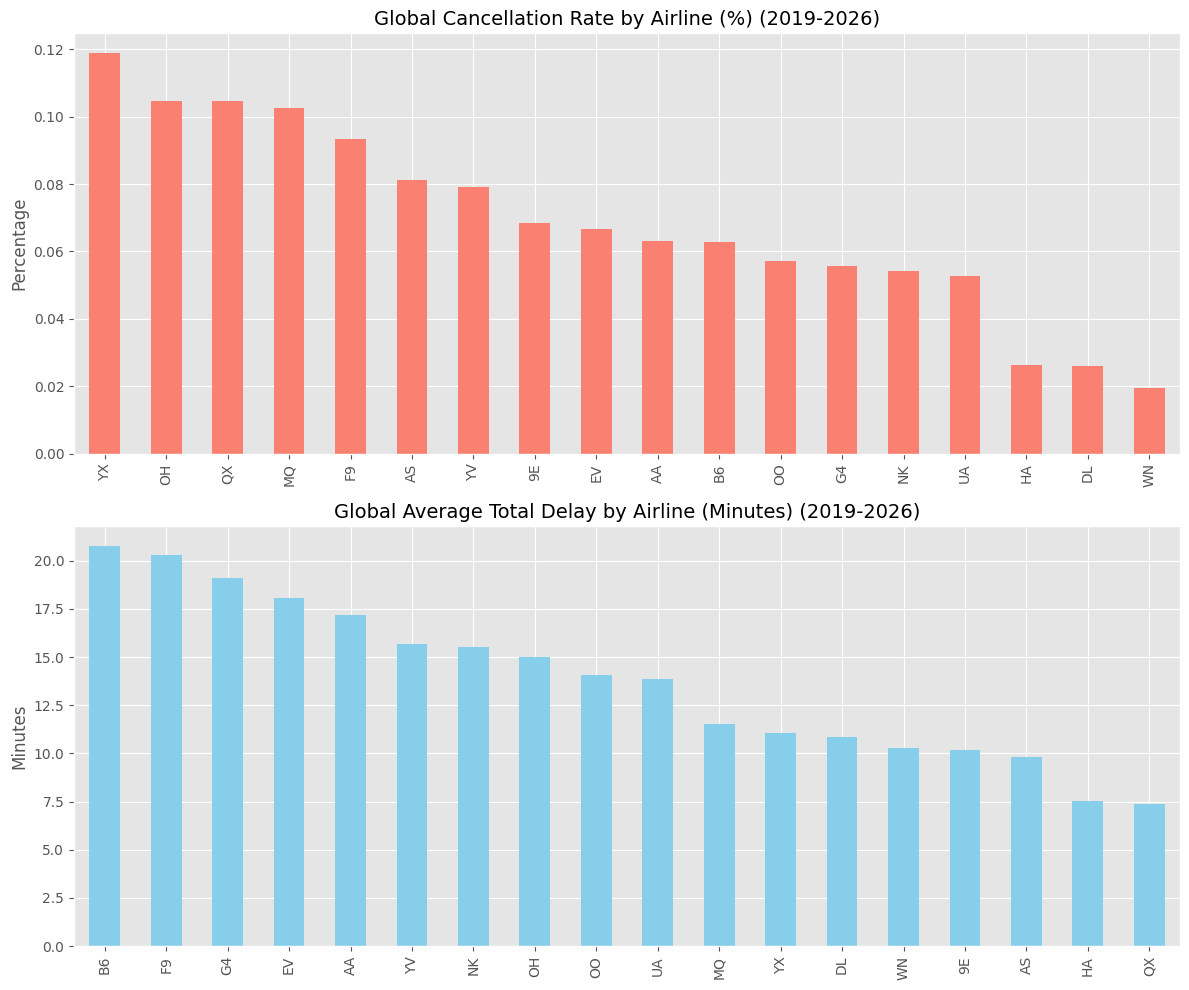


--- Global Hourly Cancellation Risk (%) ---
15    0.080139
20    0.078205
14    0.077507
4     0.077160
22    0.077082
dtype: float64


In [13]:

import matplotlib.pyplot as plt

# 1. Define paths for your Kaggle environment
input_dir = "/kaggle/working/clean_dataset"
file_pattern = os.path.join(input_dir, "bts_ontime_*_clean.csv")
clean_files = sorted(glob.glob(file_pattern))

# Dictionaries to accumulate raw data across all files
airline_counts = {}
hourly_counts = {}

print("Aggregating statistics across all data files...")

# 2. Process each file one-by-one to save memory
for file_path in clean_files:
    file_name = os.path.basename(file_path)
    print(f"Reading {file_name}...")
    
    df = pd.read_csv(file_path, low_memory=False)
    
    # Extract the departure hour from CRSDepTime (HHMM format)
    df['Dep_Hour'] = (df['CRSDepTime'] // 100).astype(int)
    
    # --- Aggregate Airline Metrics ---
    airline_grp = df.groupby('Reporting_Airline').agg(
        total_flights=('Flights', 'sum'),
        cancelled_flights=('Cancelled', 'sum'),
        total_delay_min=('Total_Delay', 'sum')
    ).reset_index()
    
    for _, row in airline_grp.iterrows():
        carrier = row['Reporting_Airline']
        if carrier not in airline_counts:
            airline_counts[carrier] = {'flights': 0, 'cancelled': 0, 'delay_min': 0}
        airline_counts[carrier]['flights'] += row['total_flights']
        airline_counts[carrier]['cancelled'] += row['cancelled_flights']
        airline_counts[carrier]['delay_min'] += row['total_delay_min']
        
    # --- Aggregate Hourly Metrics ---
    hourly_grp = df.groupby('Dep_Hour').agg(
        total_flights=('Flights', 'sum'),
        cancelled_flights=('Cancelled', 'sum')
    ).reset_index()
    
    for _, row in hourly_grp.iterrows():
        hour = int(row['Dep_Hour'])
        if hour not in hourly_counts:
            hourly_counts[hour] = {'flights': 0, 'cancelled': 0}
        hourly_counts[hour]['flights'] += row['total_flights']
        hourly_counts[hour]['cancelled'] += row['cancelled_flights']

# 3. Compute final global rates/averages using the combined data
# Convert Airline dictionary to DataFrame
df_airline_global = pd.DataFrame.from_dict(airline_counts, orient='index')
airline_cancel = (df_airline_global['cancelled'] / df_airline_global['flights'] * 100).sort_values(ascending=False)
airline_delay = (df_airline_global['delay_min'] / df_airline_global['flights']).sort_values(ascending=False)

# Convert Hourly dictionary to DataFrame
df_hourly_global = pd.DataFrame.from_dict(hourly_counts, orient='index')
hourly_cancel = (df_hourly_global['cancelled'] / df_hourly_global['flights'] * 100)

# 4. Generate your Visualizations
plt.style.use('ggplot')
plt.figure(figsize=(12, 10))

# Plot 1: Global Cancellations
plt.subplot(2, 1, 1)
airline_cancel.plot(kind='bar', color='salmon')
plt.title('Global Cancellation Rate by Airline (%) (2019-2026)', fontsize=14)
plt.ylabel('Percentage')

# Plot 2: Global Delays
plt.subplot(2, 1, 2)
airline_delay.plot(kind='bar', color='skyblue')
plt.title('Global Average Total Delay by Airline (Minutes) (2019-2026)', fontsize=14)
plt.ylabel('Minutes')

plt.tight_layout()
plt.show()

# 5. Print the global hourly results
print("\n--- Global Hourly Cancellation Risk (%) ---")
print(hourly_cancel.sort_values(ascending=False).head(5))

# DELAYS RATE , HOURLY , day of week and type.

Aggregating multi-year metrics...
Analyzing bts_ontime_2019_clean.csv...
Analyzing bts_ontime_2020_clean.csv...
Analyzing bts_ontime_2021_clean.csv...
Analyzing bts_ontime_2022_clean.csv...
Analyzing bts_ontime_2023_clean.csv...
Analyzing bts_ontime_2024_clean.csv...
Analyzing bts_ontime_2025_clean.csv...
Analyzing bts_ontime_2026_clean.csv...


/tmp/ipykernel_16/2142329884.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hour_stats.index, y=hour_stats['Avg_Delay'], palette='magma')
/tmp/ipykernel_16/2142329884.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=day_stats.index, y=day_stats['Avg_Delay'], palette='viridis')


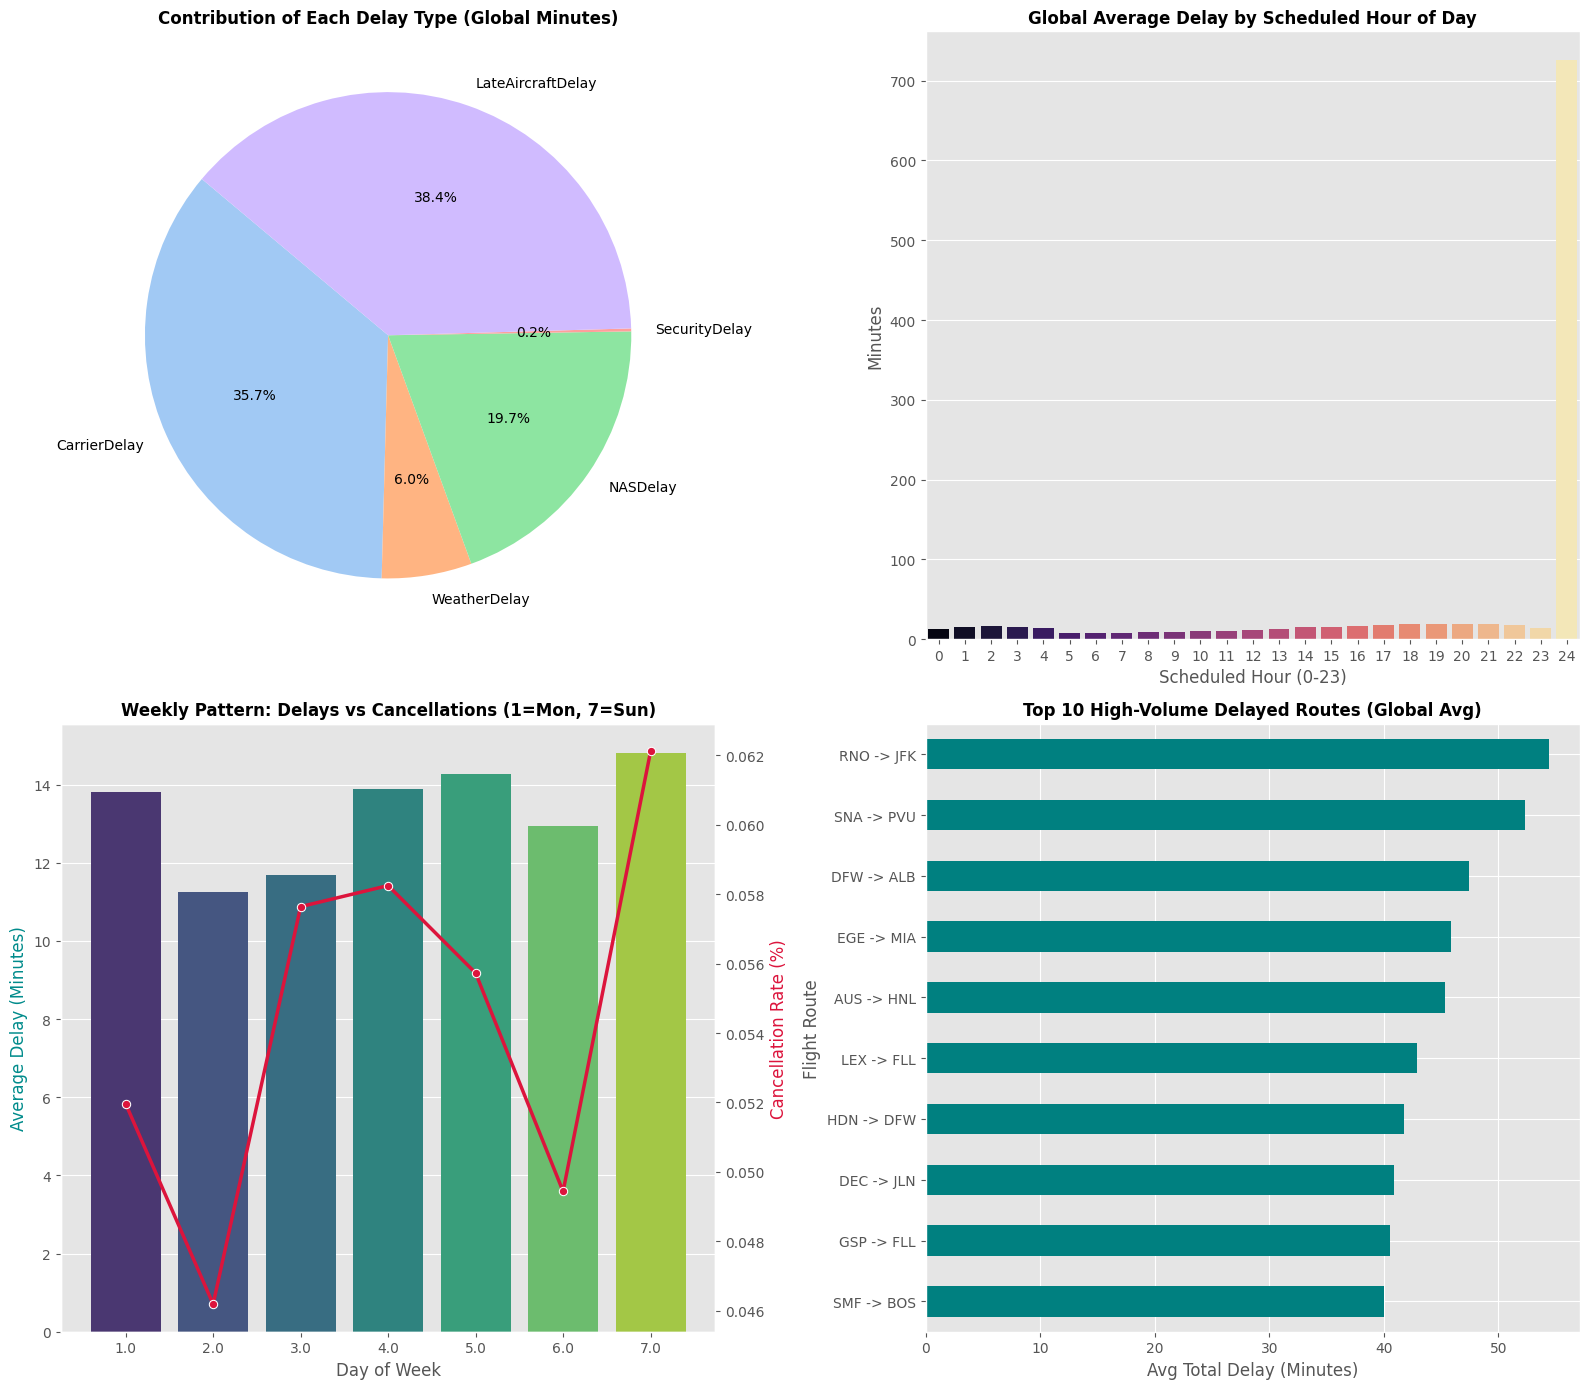


--- Global Delay Type Share Breakdown (Total Minutes) ---
LateAircraftDelay    231139385.0
CarrierDelay         214607924.0
NASDelay             118431520.0
WeatherDelay          35974629.0
SecurityDelay          1168862.0
dtype: float64

--- Global Day of Week Cancellation Rates ---
7.0    0.062104
4.0    0.058244
3.0    0.057638
5.0    0.055727
1.0    0.051963
6.0    0.049441
2.0    0.046197
Name: Cancellation_Rate_%, dtype: float64


In [14]:
import seaborn as sns
# 1. Define paths for your Kaggle environment
input_dir = "/kaggle/working/clean_dataset"
file_pattern = os.path.join(input_dir, "bts_ontime_*_clean.csv")
clean_files = sorted(glob.glob(file_pattern))

# Initialize comprehensive aggregation containers
delay_types = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
global_delay_sums = pd.Series(0, index=delay_types)

# Dicts to accumulate day, hour, and route structures
day_accumulator = {}
hour_accumulator = {}
route_accumulator = {}

print("Aggregating multi-year metrics...")

# 2. Process each file sequentially to minimize memory footprint
for file_path in clean_files:
    file_name = os.path.basename(file_path)
    print(f"Analyzing {file_name}...")
    
    df = pd.read_csv(file_path, low_memory=False)
    
    # Feature engineering for hourly distribution and routing strings
    df['Dep_Hour'] = (df['CRSDepTime'] // 100).astype(int)
    df['Route'] = df['Origin'] + ' -> ' + df['Dest']
    
    # Accumulate global delay sums for the pie chart
    global_delay_sums += df[delay_types].sum()
    
    # Day of Week Aggregation (Map step)
    day_grp = df.groupby('DayOfWeek').agg(
        flights=('Flights', 'sum'),
        total_delay=('Total_Delay', 'sum'),
        cancelled=('Cancelled', 'sum')
    ).reset_index()
    for _, row in day_grp.iterrows():
        d = row['DayOfWeek']
        if d not in day_accumulator: day_accumulator[d] = {'f': 0, 'td': 0, 'c': 0}
        day_accumulator[d]['f'] += row['flights']
        day_accumulator[d]['td'] += row['total_delay']
        day_accumulator[d]['c'] += row['cancelled']
        
    # Hourly Aggregation (Map step)
    hour_grp = df.groupby('Dep_Hour').agg(
        flights=('Flights', 'sum'),
        total_delay=('Total_Delay', 'sum')
    ).reset_index()
    for _, row in hour_grp.iterrows():
        h = int(row['Dep_Hour'])
        if h not in hour_accumulator: hour_accumulator[h] = {'f': 0, 'td': 0}
        hour_accumulator[h]['f'] += row['flights']
        hour_accumulator[h]['td'] += row['total_delay']
        
    # Route Aggregation (Map step)
    route_grp = df.groupby('Route').agg(
        flights=('Flights', 'sum'),
        total_delay=('Total_Delay', 'sum')
    ).reset_index()
    for _, row in route_grp.iterrows():
        r = row['Route']
        if r not in route_accumulator: route_accumulator[r] = {'f': 0, 'td': 0}
        route_accumulator[r]['f'] += row['flights']
        route_accumulator[r]['td'] += row['total_delay']

# 3. Final Global Reductions
# Rebuild DataFrames from accumulators and evaluate real weights/means
day_stats = pd.DataFrame.from_dict(day_accumulator, orient='index').sort_index()
day_stats['Avg_Delay'] = day_stats['td'] / day_stats['f']
day_stats['Cancellation_Rate_%'] = (day_stats['c'] / day_stats['f']) * 100

hour_stats = pd.DataFrame.from_dict(hour_accumulator, orient='index').sort_index()
hour_stats['Avg_Delay'] = hour_stats['td'] / hour_stats['f']

route_stats = pd.DataFrame.from_dict(route_accumulator, orient='index')
# Filter out sparse routes with less than 500 lifetime flights to ensure statistical significance
route_stats = route_stats[route_stats['f'] >= 500]
route_delay = (route_stats['td'] / route_stats['f']).sort_values(ascending=False).head(10)

# 4. Generate Plot Grid Matrix
plt.figure(figsize=(16, 14))
plt.style.use('seaborn-v0_8-muted')

# Plot A: Global Pie Chart of Delay Causes
plt.subplot(2, 2, 1)
plt.pie(global_delay_sums, labels=global_delay_sums.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Contribution of Each Delay Type (Global Minutes)', fontsize=12, fontweight='bold')

# Plot B: Hourly Delay Distribution Pattern
plt.subplot(2, 2, 2)
sns.barplot(x=hour_stats.index, y=hour_stats['Avg_Delay'], palette='magma')
plt.title('Global Average Delay by Scheduled Hour of Day', fontsize=12, fontweight='bold')
plt.xlabel('Scheduled Hour (0-23)')
plt.ylabel('Minutes')

# Plot C: Avg Delay and Cancellations by Day of Week
plt.subplot(2, 2, 3)
ax1 = sns.barplot(x=day_stats.index, y=day_stats['Avg_Delay'], palette='viridis')
plt.title('Weekly Pattern: Delays vs Cancellations (1=Mon, 7=Sun)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Delay (Minutes)', color='darkcyan')
ax1.set_xlabel('Day of Week')

ax2 = ax1.twinx()
sns.lineplot(x=day_stats.index - 1, y=day_stats['Cancellation_Rate_%'], marker='o', color='crimson', linewidth=2.5, ax=ax2)
ax2.set_ylabel('Cancellation Rate (%)', color='crimson')
ax2.grid(False)

# Plot D: Top 10 Delayed Global Routes (Filtered for high volume)
plt.subplot(2, 2, 4)
route_delay.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()  # Puts the most delayed route right at the top
plt.title('Top 10 High-Volume Delayed Routes (Global Avg)', fontsize=12, fontweight='bold')
plt.xlabel('Avg Total Delay (Minutes)')
plt.ylabel('Flight Route')

plt.tight_layout()
plt.show()

# 5. Summarized Output Displays
print("\n--- Global Delay Type Share Breakdown (Total Minutes) ---")
print(global_delay_sums.sort_values(ascending=False))

print("\n--- Global Day of Week Cancellation Rates ---")
print(day_stats['Cancellation_Rate_%'].sort_values(ascending=False))

# Global Feature Correlation Analysis: Out-of-core covariance accumulation to calculate and visualize feature correlations across all years.

Calculating global feature correlations across all datasets...


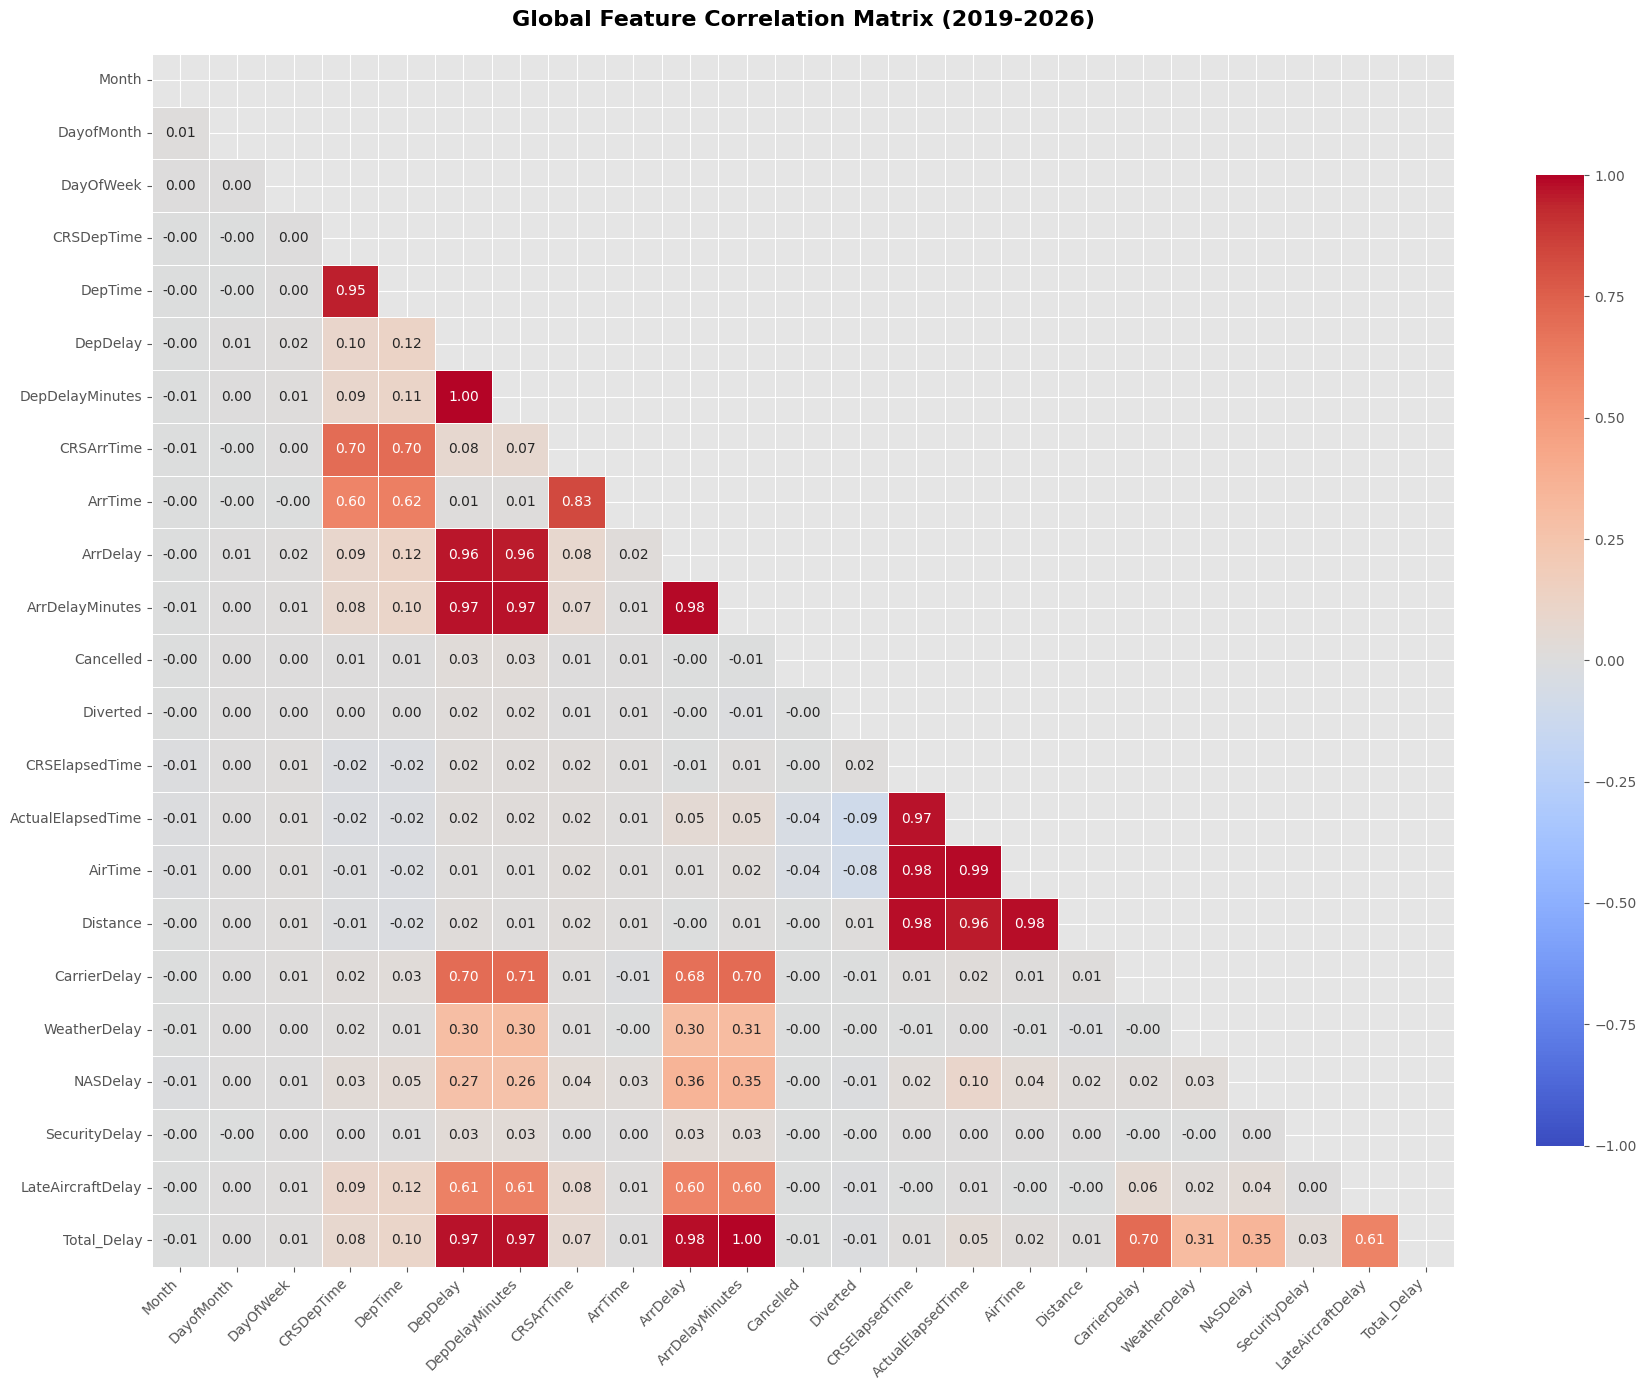


--- Top Strongest Feature Correlations (Excluding Self-Correlation) ---
        Feature_1       Feature_2  Correlation_R  Absolute_R
  ArrDelayMinutes     Total_Delay       0.998499    0.998499
         DepDelay DepDelayMinutes       0.997530    0.997530
ActualElapsedTime         AirTime       0.986847    0.986847
         ArrDelay ArrDelayMinutes       0.984453    0.984453
   CRSElapsedTime        Distance       0.982625    0.982625
          AirTime  CRSElapsedTime       0.982185    0.982185
         ArrDelay     Total_Delay       0.979662    0.979662
          AirTime        Distance       0.977187    0.977187
  ArrDelayMinutes DepDelayMinutes       0.974696    0.974696
  DepDelayMinutes     Total_Delay       0.973492    0.973492


In [15]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define paths for your Kaggle environment
input_dir = "/kaggle/working/clean_dataset"
file_pattern = os.path.join(input_dir, "bts_ontime_*_clean.csv")
clean_files = sorted(glob.glob(file_pattern))

# Select meaningful numerical features for correlation (excluding constant identifiers like Flights)
features = [
    'Month', 'DayofMonth', 'DayOfWeek', 'CRSDepTime', 'DepTime', 
    'DepDelay', 'DepDelayMinutes', 'CRSArrTime', 'ArrTime', 
    'ArrDelay', 'ArrDelayMinutes', 'Cancelled', 'Diverted', 
    'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'Distance', 
    'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 
    'LateAircraftDelay', 'Total_Delay'
]

# Initialize running accumulators for global correlation math
n_features = len(features)
global_mean = np.zeros(n_features)
global_covariance = np.zeros((n_features, n_features))
total_rows = 0

print("Calculating global feature correlations across all datasets...")

# 2. First pass: Calculate global grand means for each feature file-by-file
for file_path in clean_files:
    df = pd.read_csv(file_path, usecols=features, low_memory=False).dropna()
    X = df[features].values
    count = X.shape[0]
    
    if count == 0:
        continue
        
    # Update running global mean
    total_rows += count
    global_mean += (X.sum(axis=0) - count * global_mean) / total_rows

# 3. Second pass: Accumulate deviations from the global mean to build the covariance matrix
for file_path in clean_files:
    df = pd.read_csv(file_path, usecols=features, low_memory=False).dropna()
    X = df[features].values
    
    # Subtract the global mean from this chunk's data
    deviations = X - global_mean
    global_covariance += np.dot(deviations.T, deviations)

# 4. Final step: Divide by total rows to get covariance, then scale into Pearson Correlation (R)
global_covariance /= (total_rows - 1)
std_devs = np.sqrt(np.diag(global_covariance))
global_correlation = global_covariance / np.outer(std_devs, std_devs)

# Convert back to a clean Pandas DataFrame
df_corr = pd.DataFrame(global_correlation, index=features, columns=features)

# 5. Visualize the Global Correlation Heatmap
plt.figure(figsize=(18, 14))
# Generate a mask for the upper triangle to make it easier to read
mask = np.triu(np.ones_like(df_corr, dtype=bool))

sns.heatmap(
    df_corr, 
    mask=mask, 
    cmap='coolwarm', 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    annot=True, 
    fmt=".2f", 
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Global Feature Correlation Matrix (2019-2026)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Print out the strongest relationships ---
print("\n--- Top Strongest Feature Correlations (Excluding Self-Correlation) ---")
corr_pairs = df_corr.unstack().reset_index()
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation_R']
# Remove duplicates and self-correlations
corr_pairs = corr_pairs[corr_pairs['Feature_1'] < corr_pairs['Feature_2']]
corr_pairs['Absolute_R'] = corr_pairs['Correlation_R'].abs()

print(corr_pairs.sort_values(by='Absolute_R', ascending=False).head(10).to_string(index=False))

# Target Variable (WEATHER_DELAY) Distribution Analysis

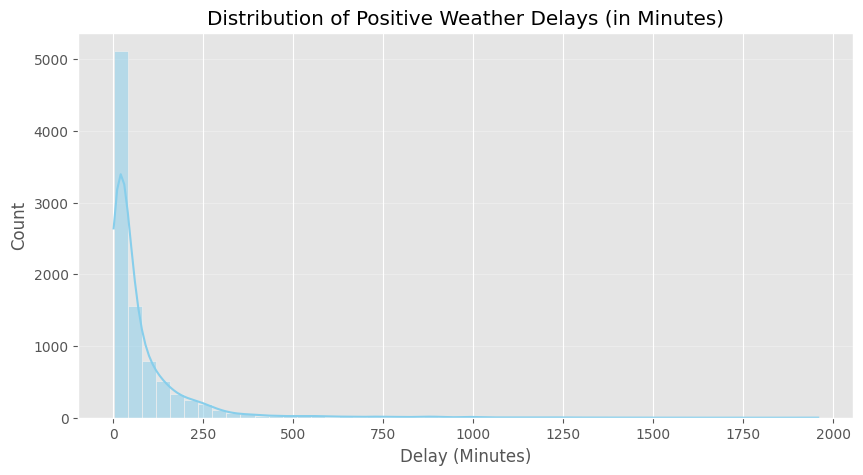

count    9292.000000
mean       83.608158
std       146.106347
min         1.000000
25%        15.000000
50%        34.000000
75%        92.000000
max      1958.000000
Name: WeatherDelay, dtype: float64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for records where there actually is a weather delay
weather_delays = df[df['WeatherDelay'] > 0]['WeatherDelay']

plt.figure(figsize=(10, 5))
sns.histplot(weather_delays, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Positive Weather Delays (in Minutes)')
plt.xlabel('Delay (Minutes)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Descriptive statistics
print(weather_delays.describe())

# Feature Distributions Before and After Imputation

# Correlation Heatmaps (Feature-Feature & Feature-Target)

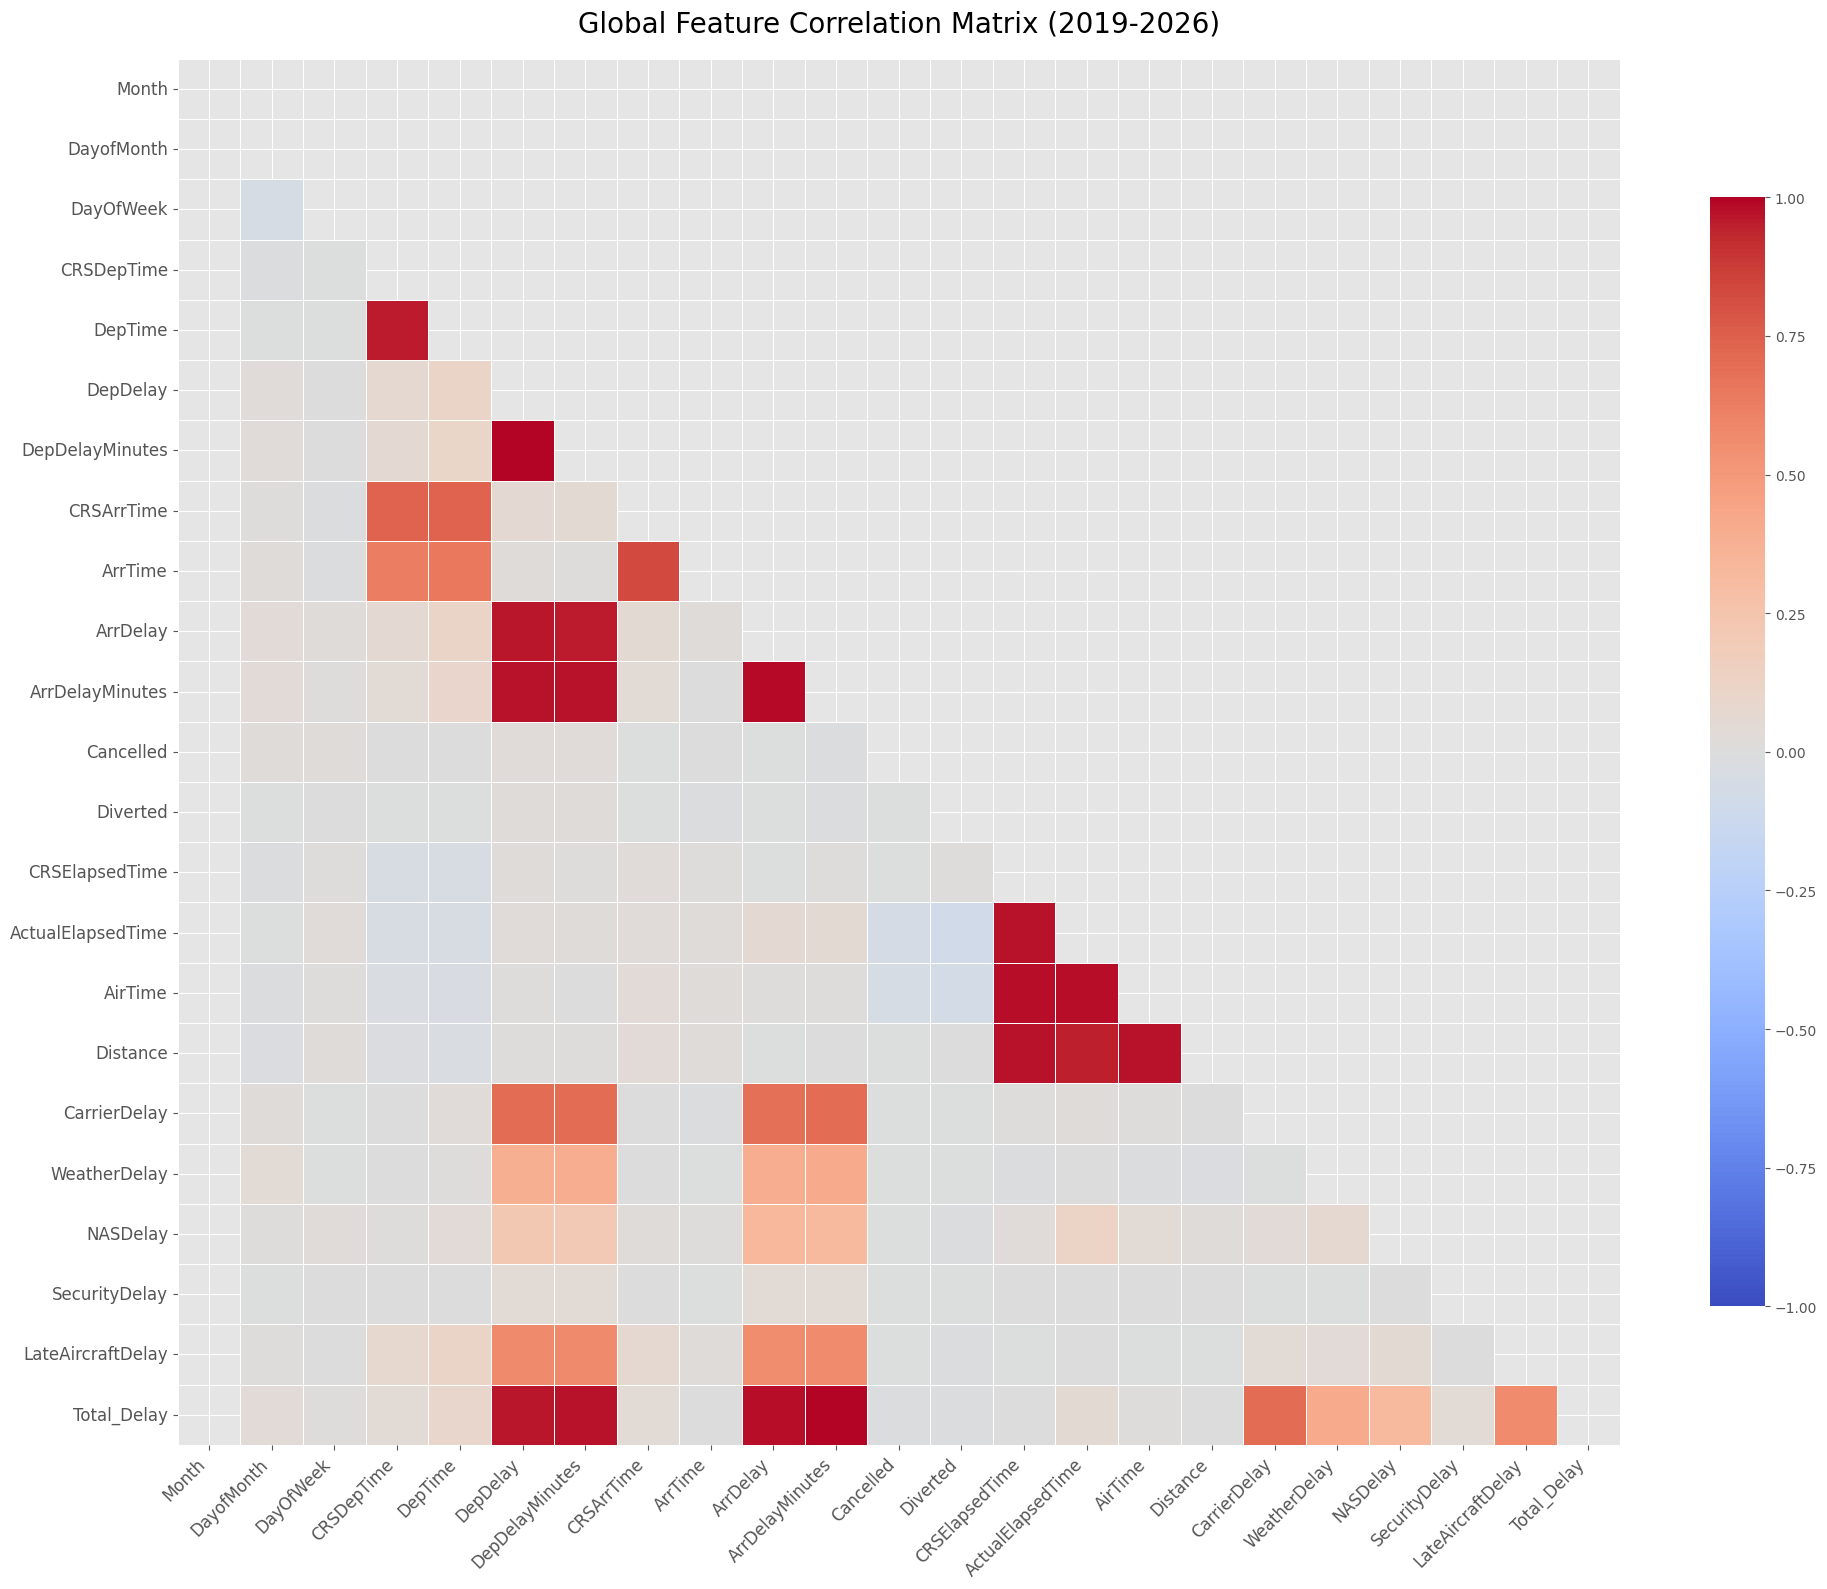

--- Correlation with Target Variable (WeatherDelay) ---
WeatherDelay         1.000000
ArrDelayMinutes      0.406757
Total_Delay          0.406559
ArrDelay             0.393426
DepDelayMinutes      0.392230
DepDelay             0.388798
NASDelay             0.064234
DayofMonth           0.039488
LateAircraftDelay    0.035257
DepTime              0.012205
ActualElapsedTime    0.004046
CRSArrTime           0.003410
CRSDepTime           0.003004
SecurityDelay       -0.000165
Cancelled           -0.002008
ArrTime             -0.002975
Diverted            -0.003133
CarrierDelay        -0.005720
DayOfWeek           -0.007780
CRSElapsedTime      -0.012395
AirTime             -0.013668
Distance            -0.016311
Month                     NaN
Name: WeatherDelay, dtype: float64


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Make the canvas significantly larger
plt.figure(figsize=(20, 16))

# 2. Recalculate correlation matrix
df_corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(df_corr, dtype=bool))

# 3. Plot WITHOUT annotations (annot=False) to clear up the clutter
sns.heatmap(
    df_corr, 
    mask=mask, 
    annot=False,        # This removes the overlapping numbers
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,     # Adds clean grid lines between squares
    cbar_kws={"shrink": 0.8}
)

# 4. Make font sizes readable
plt.title('Global Feature Correlation Matrix (2019-2026)', fontsize=20, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

# Isolate Feature-to-Target correlation specifically
# Isolate Target correlation specifically using the correct mixed-case name
print("--- Correlation with Target Variable (WeatherDelay) ---")
print(df_corr['WeatherDelay'].sort_values(ascending=False))

# Outlier Detection and Capping Results

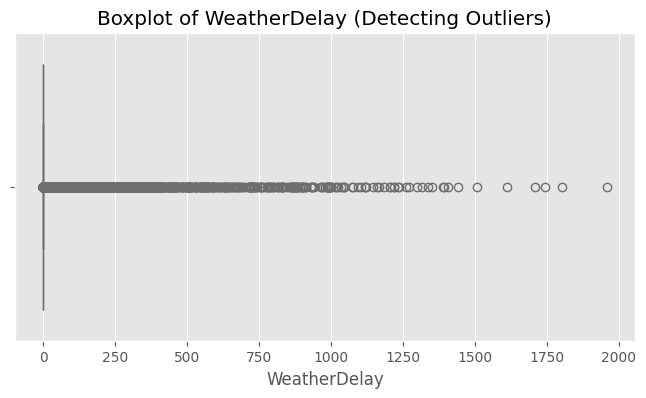

The 99th percentile value is: 28.0 minutes.
Number of rows above 99th percentile: 5129


In [18]:
# Boxplot to visualize outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['WeatherDelay'], color='lightcoral')
plt.title('Boxplot of WeatherDelay (Detecting Outliers)')
plt.show()

# Capping outliers at the 99th percentile
q_99 = df['WeatherDelay'].quantile(0.99)
print(f"The 99th percentile value is: {q_99} minutes.")

outliers_count = (df['WeatherDelay'] > q_99).sum()
print(f"Number of rows above 99th percentile: {outliers_count}")

# Apply the cap
df['WeatherDelay_Capped'] = np.where(df['WeatherDelay'] > q_99, q_99, df['WeatherDelay'])

# Conditional Probability: Does a Weather/Departure Delay guarantee an Arrival Delay?

In [19]:
import pandas as pd

# Define what constitutes a "delayed" flight (e.g., > 15 minutes is the FAA standard)
faa_threshold = 15

total_flights = len(df)
arr_delayed = df[df['ArrDelayMinutes'] >= faa_threshold]
dep_delayed = df[df['DepDelayMinutes'] >= faa_threshold]
weather_delayed = df[df['WeatherDelay'] > 0]

# 1. Probability that a departure delay results in an arrival delay
dep_and_arr = df[(df['DepDelayMinutes'] >= faa_threshold) & (df['ArrDelayMinutes'] >= faa_threshold)]
p_arr_given_dep = (len(dep_and_arr) / len(dep_delayed)) * 100

# 2. Probability that a weather delay results in an arrival delay
weather_and_arr = df[(df['WeatherDelay'] > 0) & (df['ArrDelayMinutes'] >= faa_threshold)]
p_arr_given_weather = (len(weather_and_arr) / len(weather_delayed)) * 100

print(f"Smart Stat 1: Conditional Probabilities")
print(f"----------------------------------------")
print(f"Probability a flight arrives late GIVEN it departed late: {p_arr_given_dep:.2f}%")
print(f"Probability a flight arrives late GIVEN it had a weather delay: {p_arr_given_weather:.2f}%")

Smart Stat 1: Conditional Probabilities
----------------------------------------
Probability a flight arrives late GIVEN it departed late: 77.74%
Probability a flight arrives late GIVEN it had a weather delay: 100.00%


# Variance Inflation Factor (VIF): Proving Multicollinearity

 A VIF score above 5 or 10 indicates severe multicollinearity (PROBLEM).

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select the overlapping features
features = df[['DepDelayMinutes', 'WeatherDelay', 'ArrDelayMinutes']].dropna()

# Calculate VIF for each
vif_data = pd.DataFrame()
vif_data["Feature"] = features.columns
vif_data["VIF"] = [variance_inflation_factor(features.values, i) for i in range(len(features.columns))]

print("\nSmart Stat 2: Variance Inflation Factor (VIF)")
print(f"---------------------------------------------")
print(vif_data.to_string(index=False))


Smart Stat 2: Variance Inflation Factor (VIF)
---------------------------------------------
        Feature       VIF
DepDelayMinutes 20.386087
   WeatherDelay  1.201102
ArrDelayMinutes 20.661923


# The Mediation Analysis Matrix (Three-Way Correlation)
showing how WeatherDelay acts as a driver for both DepDelayMinutes and ArrDelayMinutes

In [21]:
# Focus strictly on the interaction trio
trio_corr = df[['WeatherDelay', 'DepDelayMinutes', 'ArrDelayMinutes']].corr()

print("\nSmart Stat 3: Inter-Collision Matrix")
print(f"------------------------------------")
print(trio_corr)


Smart Stat 3: Inter-Collision Matrix
------------------------------------
                 WeatherDelay  DepDelayMinutes  ArrDelayMinutes
WeatherDelay         1.000000         0.392230         0.406757
DepDelayMinutes      0.392230         1.000000         0.973219
ArrDelayMinutes      0.406757         0.973219         1.000000


# The Metric to Check: Lost Weather Variance
To see if any weather delays are "hidden" or disconnected from arrival delays, we need to isolate the flights where a Weather Delay occurred, but the Arrival Delay was zero or negative (meaning the flight arrived on time or early despite the weather).

In [22]:
# 1. Total flights with a known weather delay
flights_with_weather = df[df['WeatherDelay'] > 0]
total_weather_cases = len(flights_with_weather)

# 2. Weather occurred, but flight was NOT late arriving (ArrDelayMinutes == 0)
weather_but_on_time_arr = flights_with_weather[flights_with_weather['ArrDelayMinutes'] == 0]
num_lost_to_arr = len(weather_but_on_time_arr)

# 3. Weather occurred, but flight was NOT late departing (DepDelayMinutes == 0)
weather_but_on_time_dep = flights_with_weather[flights_with_weather['DepDelayMinutes'] == 0]
num_lost_to_dep = len(weather_but_on_time_dep)

# Calculate percentages
pct_lost_arr = (num_lost_to_arr / total_weather_cases) * 100
pct_lost_dep = (num_lost_to_dep / total_weather_cases) * 100

print("--- Weather Delay Leakage Analysis ---")
print(f"Total flights with weather delays: {total_weather_cases}")
print(f"Flights with weather delays that arrived EXACTLY ON-TIME/EARLY: {num_lost_to_arr} ({pct_lost_arr:.3f}%)")
print(f"Flights with weather delays that departed EXACTLY ON-TIME/EARLY: {num_lost_to_dep} ({pct_lost_dep:.3f}%)")

--- Weather Delay Leakage Analysis ---
Total flights with weather delays: 9292
Flights with weather delays that arrived EXACTLY ON-TIME/EARLY: 0 (0.000%)
Flights with weather delays that departed EXACTLY ON-TIME/EARLY: 19 (0.204%)


# Comparison: Where is Weather More Strongly Tied?

In [23]:
# Calculate the average discrepancy
avg_dep_delay_with_weather = flights_with_weather['DepDelayMinutes'].mean()
avg_arr_delay_with_weather = flights_with_weather['ArrDelayMinutes'].mean()
avg_actual_weather = flights_with_weather['WeatherDelay'].mean()

print("\n--- Severity Breakdown (When Weather Occurs) ---")
print(f"Average actual Weather Delay segments: {avg_actual_weather:.2f} minutes")
print(f"Average total Departure Delay on those flights: {avg_dep_delay_with_weather:.2f} minutes")
print(f"Average total Arrival Delay on those flights: {avg_arr_delay_with_weather:.2f} minutes")


--- Severity Breakdown (When Weather Occurs) ---
Average actual Weather Delay segments: 83.61 minutes
Average total Departure Delay on those flights: 113.47 minutes
Average total Arrival Delay on those flights: 124.85 minutes
